In [1]:
from dataclasses import replace

from hydra import compose, initialize

from config.eval import ExperimentEvalConfig
from config.train import ExperimentTrainConfig
from config.experiment import ExperimentConfig
from utils.plot import MetricIdx, plot_metrics_vs_perturbation, plot_model_heatmap, plot_transferability, plot_images_side_by_side

In [2]:
def load_config(name):
    with initialize(version_base=None, config_path="pkg://experiments"):
        cfg = compose(config_name=name)
    return ExperimentConfig(
        train=ExperimentTrainConfig(**cfg["train"]),
        eval=ExperimentEvalConfig(**cfg["eval"]),
        )

In [3]:
"""
to test perturbation plot (full x-axis)
"""
exp_config = load_config("perturbation_plot")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp2"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp2"),
)


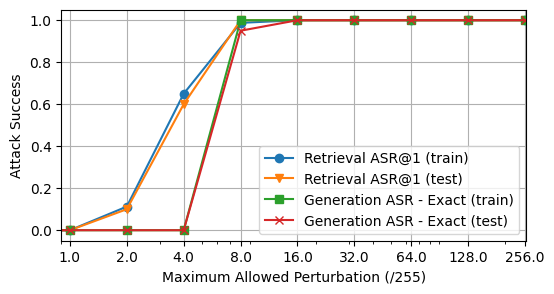

In [4]:
# need experiment -2
plot_metrics_vs_perturbation(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TRAIN, MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EXACT_TEST])

In [5]:
exp_config = load_config("heatmap_plot")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp3"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp3"),
)

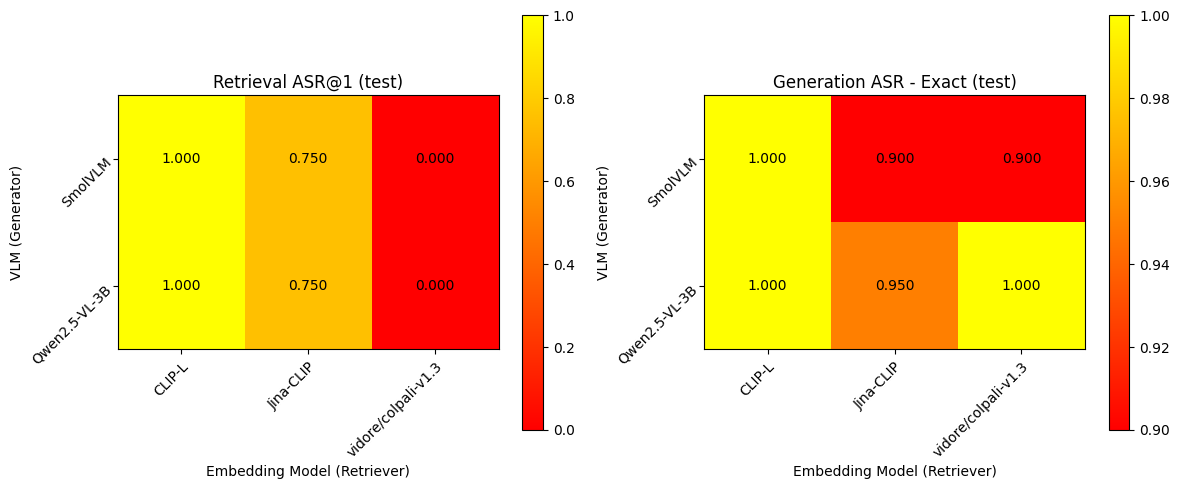

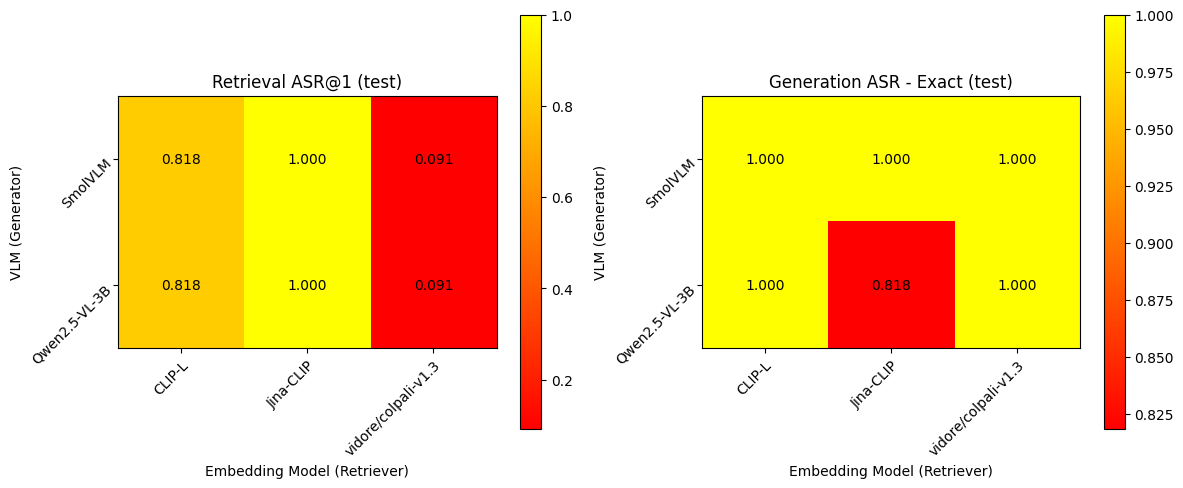

In [6]:
for ds_idx in range(2):
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL1_BEFORE, MetricIdx.RETRIEVAL_RECALL1_AFTER])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_RECALL5_BEFORE, MetricIdx.RETRIEVAL_RECALL5_AFTER])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
    plot_model_heatmap(exp_config, ds_idx=ds_idx, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [7]:
exp_config = load_config("transferability")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp4"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp4"),
)

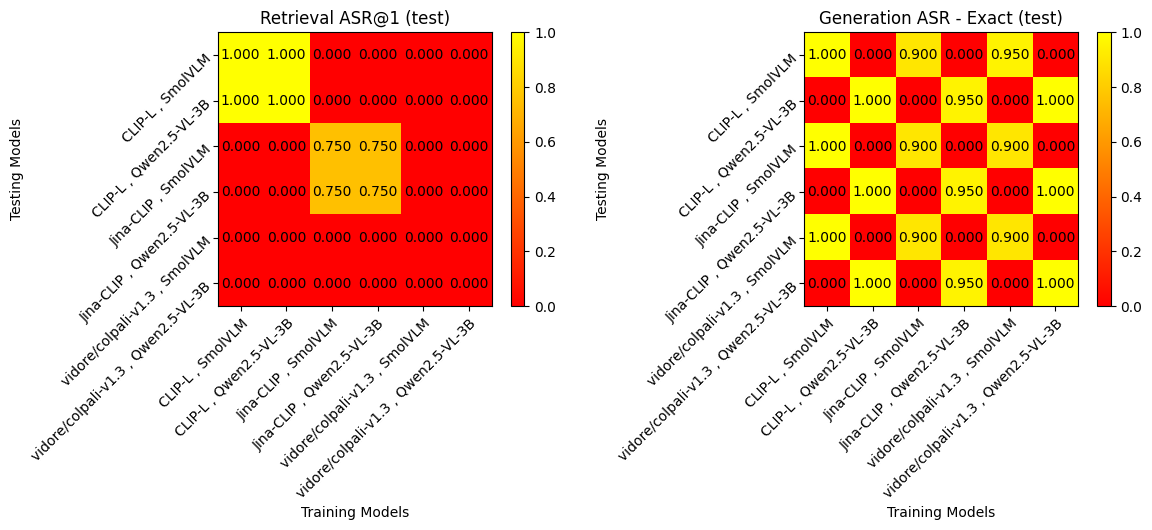

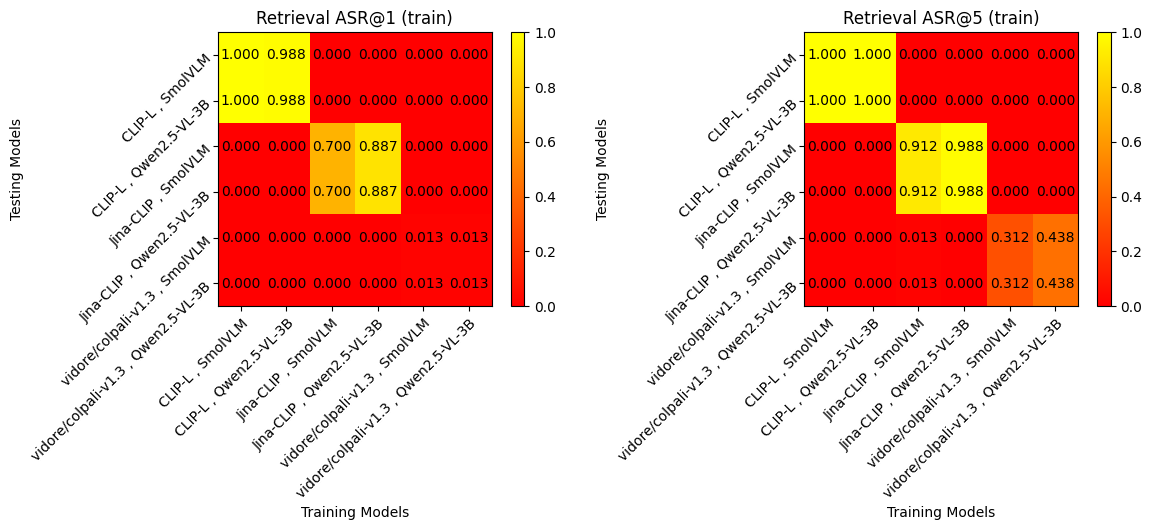

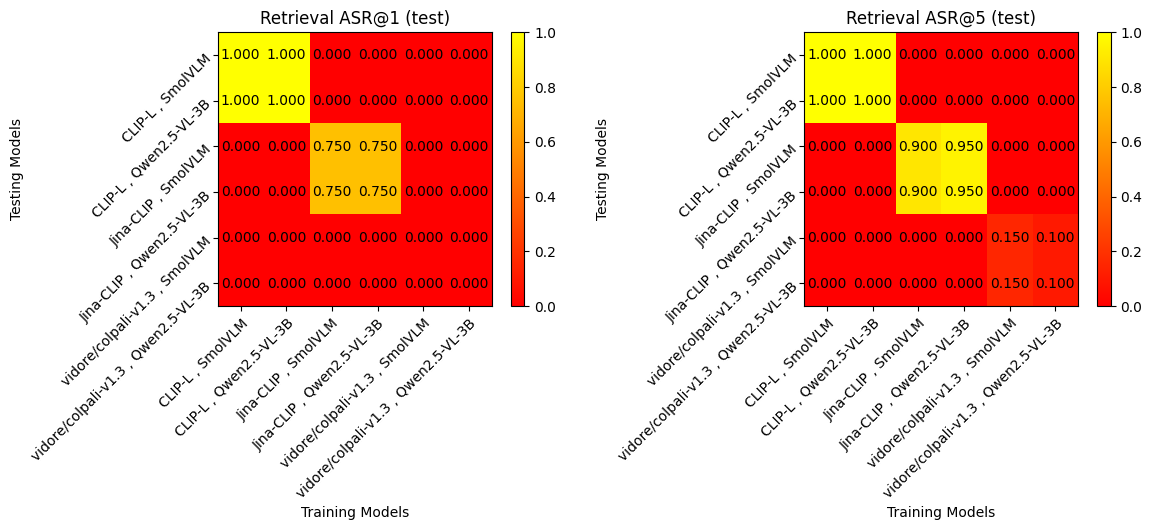

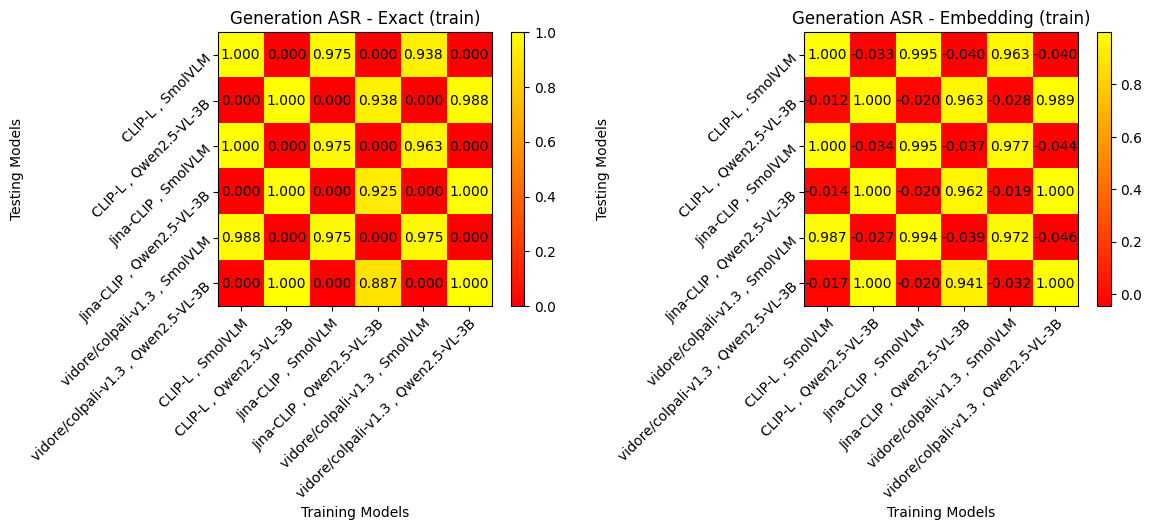

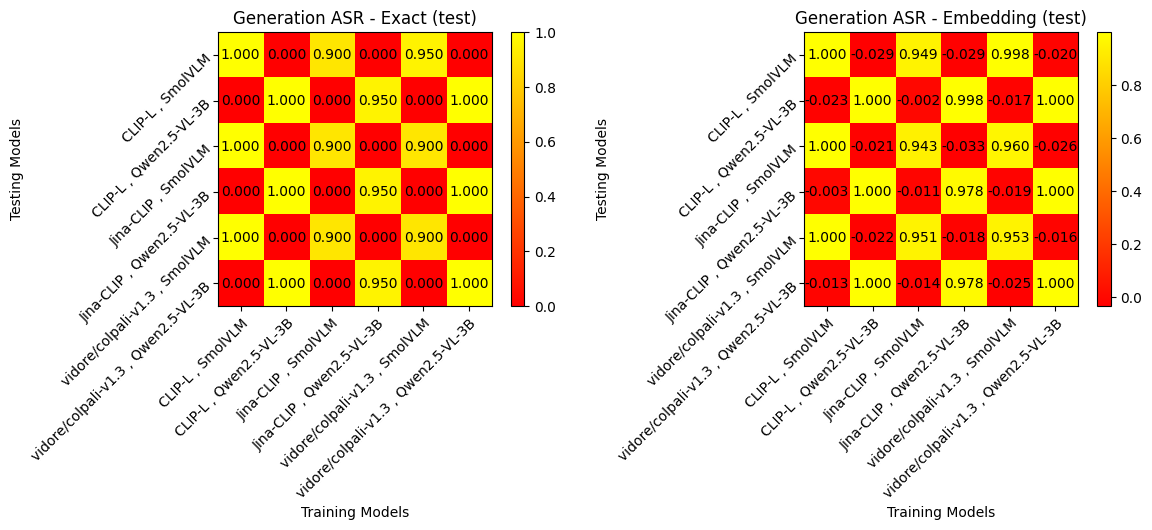

In [8]:
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TRAIN, MetricIdx.RETRIEVAL_ASR5_TRAIN])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.RETRIEVAL_ASR5_TEST])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TRAIN, MetricIdx.GENERATION_ASR_EMBED_TRAIN])
plot_transferability(exp_config, metrics_to_show=[MetricIdx.GENERATION_ASR_EXACT_TEST, MetricIdx.GENERATION_ASR_EMBED_TEST])

In [10]:
exp_config = load_config("display_images")

exp_config = ExperimentConfig(
    train = replace(exp_config.train, save_folder = exp_config.train.save_folder / "gpu/exp1"),
    eval = replace(exp_config.eval, results_folder = exp_config.eval.results_folder / "gpu/exp1"),
)

In [12]:
plot_images_side_by_side(exp_config, metrics_to_show=[MetricIdx.RETRIEVAL_ASR1_TEST, MetricIdx.GENERATION_ASR_EXACT_TEST])

ValueError: Error! Could not find file: /cs/research/infosec/projects0/dristea/mumoRAG-attacks/data/attacks/gpu/exp1/adv_img_992adba301147c84faeabd0bfd4a8341.pt! You need to train an attack with this configuration first